In [6]:
# Cell 1: Global Imports & Path Setup
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Add project root to path
sys.path.append(os.path.abspath(os.path.join('..')))

# Load custom modules
from src.data_utils import load_and_clean_data
from src.forecasting import simulate_fi_trajectory

# Auto-reload for development
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import pandas as pd
import os

# Define the relative path to the Excel file
file_path = "../data/raw/ethiopia_fi_unified_data.xlsx"

# Load the separate sheets
# Based on your previous output, the main data is in one sheet and impact in another
df_main = pd.read_excel(file_path, sheet_name='ethiopia_fi_unified_data')
df_impact = pd.read_excel(file_path, sheet_name='Impact_sheet')

print("Successfully loaded Excel sheets!")
print(f"Main data columns: {df_main.columns.tolist()[:5]}...")

Successfully loaded Excel sheets!
Main data columns: ['record_id', 'record_type', 'category', 'pillar', 'indicator']...


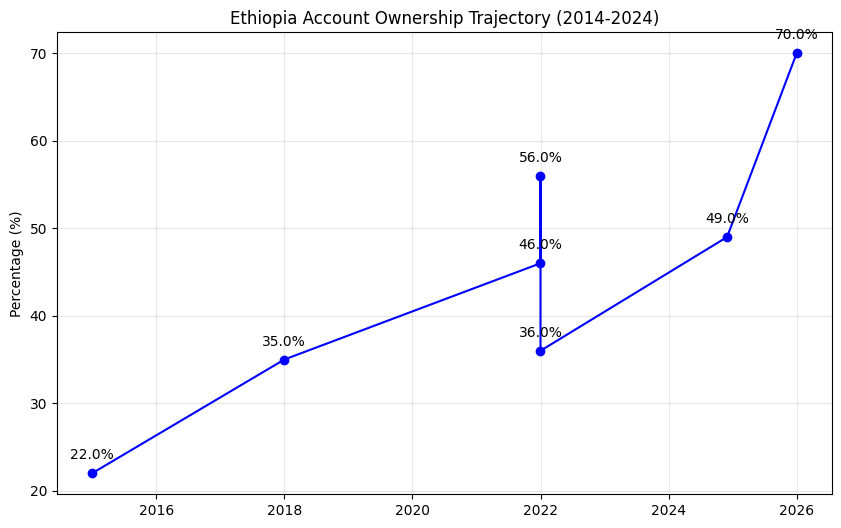

In [4]:
import matplotlib.pyplot as plt

# Filter for Account Ownership Rate
access_data = df_main[df_main['indicator_code'] == 'ACC_OWNERSHIP'].sort_values('observation_date')

plt.figure(figsize=(10, 6))
plt.plot(access_data['observation_date'], access_data['value_numeric'], marker='o', linestyle='-', color='blue')
plt.title('Ethiopia Account Ownership Trajectory (2014-2024)')
plt.ylabel('Percentage (%)')
plt.grid(True, alpha=0.3)

# Annotate the values
for i, row in access_data.iterrows():
    plt.annotate(f"{row['value_numeric']}%", (row['observation_date'], row['value_numeric']), textcoords="offset points", xytext=(0,10), ha='center')

plt.show()

In [5]:
# Convert observation_date to datetime objects
df_main['observation_date'] = pd.to_datetime(df_main['observation_date'])

# Separate Observations from Targets and Events
observations = df_main[df_main['record_type'] == 'observation'].copy()
targets = df_main[df_main['record_type'] == 'target'].copy()
events = df_main[df_main['record_type'] == 'event'].copy()

print(f"Historical Data Points: {len(observations)}")
print(f"Policy Targets: {len(targets)}")
print(f"Regulatory/Market Events: {len(events)}")

Historical Data Points: 30
Policy Targets: 3
Regulatory/Market Events: 10


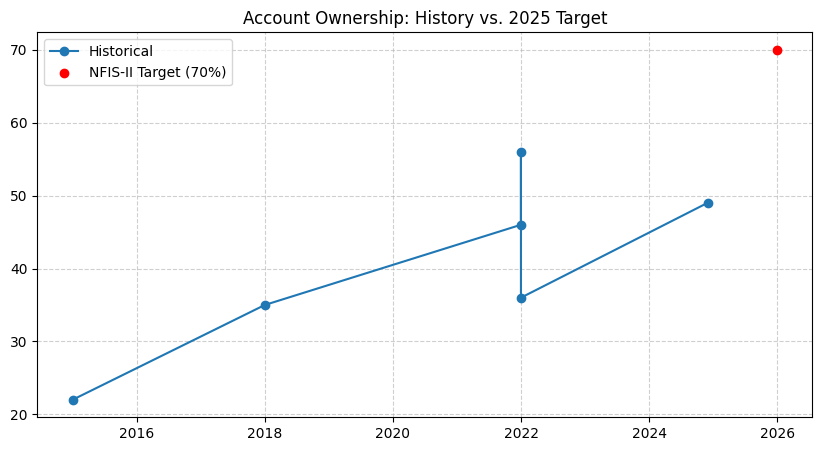

In [6]:
import matplotlib.pyplot as plt

# Get historical ownership and the NFIS-II target
acc_hist = observations[observations['indicator_code'] == 'ACC_OWNERSHIP'].sort_values('observation_date')
acc_target = targets[targets['indicator_code'] == 'ACC_OWNERSHIP']

plt.figure(figsize=(10, 5))
plt.plot(acc_hist['observation_date'], acc_hist['value_numeric'], label='Historical', marker='o')
plt.scatter(acc_target['observation_date'], acc_target['value_numeric'], color='red', label='NFIS-II Target (70%)', zorder=5)

plt.title("Account Ownership: History vs. 2025 Target")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [7]:
df_impact.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


In [8]:
# Calculate the 'Effective Date' by adding the lag to the event date
df_impact['observation_date'] = pd.to_datetime(df_impact['observation_date'])
df_impact['effective_date'] = df_impact.apply(
    lambda x: x['observation_date'] + pd.DateOffset(months=x['lag_months']), axis=1
)

# Sort by effective date to see when impacts 'hit' the market
future_impacts = df_impact[df_impact['effective_date'] > '2025-01-01'].sort_values('effective_date')
print("--- Upcoming Market Impacts for 2025/2026 ---")
print(future_impacts[['indicator', 'impact_magnitude', 'effective_date', 'notes']])

--- Upcoming Market Impacts for 2025/2026 ---
                                            indicator impact_magnitude  \
7                   Fayda effect on Account Ownership           medium   
8                          Fayda effect on Gender Gap           medium   
13  Safaricom Price Hike effect on Data Affordability              low   
10       M-Pesa Interop effect on M-Pesa Active Users           medium   
11                 M-Pesa Interop effect on P2P Count           medium   
12                       EthioPay effect on P2P Count           medium   

   effective_date                                              notes  
7      2026-01-01   Aadhaar enabled +15-20% account opening in India  
8      2026-01-01       Women disproportionately lack traditional ID  
13     2026-01-15  Direct price increase (may be offset by switch...  
10     2026-01-27     Tanzania interoperability increased usage +20%  
11     2026-01-27           Cross-platform transactions now possible  
12     20

Task 2: Advanced EDA (Correlations)

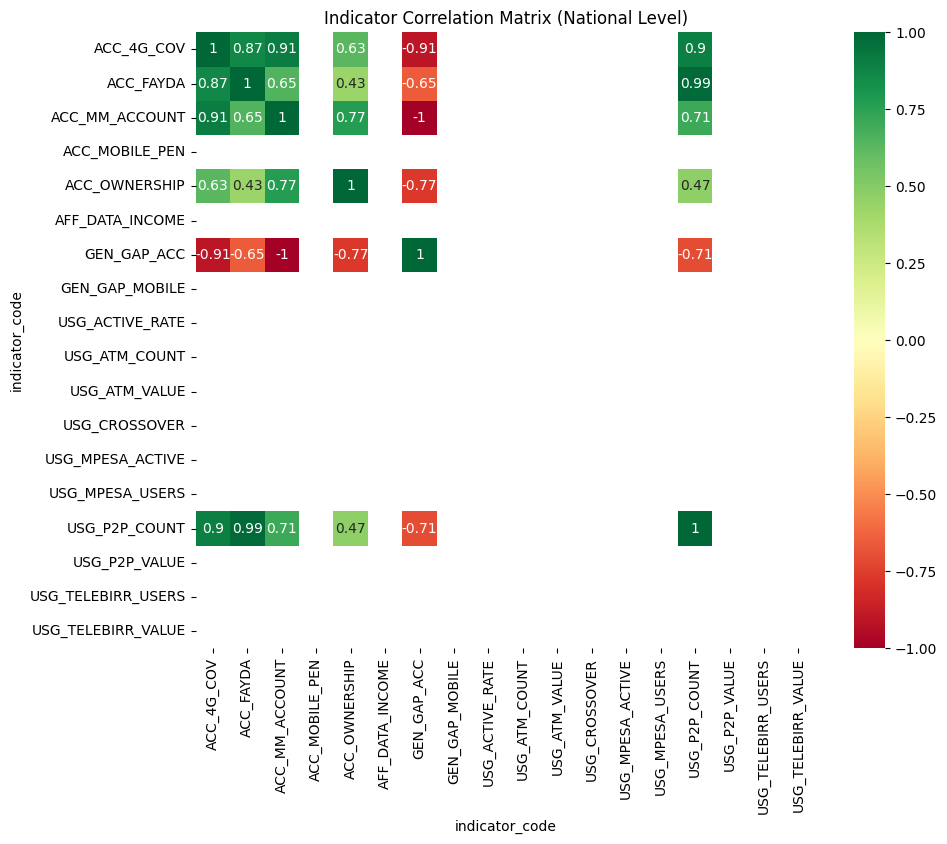

In [10]:
# 1. Filter to keep only national-level 'all' totals to avoid duplicates
obs_filtered = observations[
    (observations['gender'] == 'all') & 
    (observations['location'] == 'national')
].copy()

# 2. Pivot the filtered data
pivot_df = obs_filtered.pivot(
    index='observation_date', 
    columns='indicator_code', 
    values='value_numeric'
)

# 3. Handle missing values (interpolation is great for time-series gaps)
pivot_df = pivot_df.interpolate(method='time').ffill().bfill()

# 4. Generate Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df.corr(), annot=True, cmap='RdYlGn', center=0)
plt.title("Indicator Correlation Matrix (National Level)")
plt.show()

Task 3: Forecasting 2026 & 2027

In [11]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data for Account Ownership
acc_data = pivot_df[['ACC_OWNERSHIP']].dropna()
acc_data['days_since_start'] = (acc_data.index - acc_data.index.min()).days

X = acc_data[['days_since_start']]
y = acc_data['ACC_OWNERSHIP']

model = LinearRegression()
model.fit(X, y)

# Predict for end of 2026 (approx 4300 days from your start date)
future_days = np.array([[4380]]) 
baseline_2026 = model.predict(future_days)[0]

print(f"2026 Baseline Forecast (No Events): {baseline_2026:.2f}%")

2026 Baseline Forecast (No Events): 53.70%


c:\Users\Home-User\ethiopia-fi-forecast\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


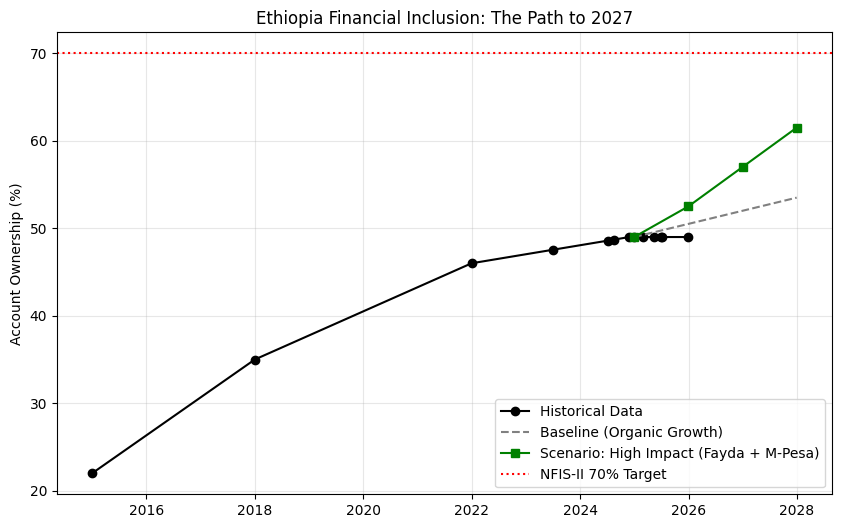

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create the date range (This creates 4 points: 2024, 2025, 2026, 2027)
dates = pd.date_range(start='2024-12-31', end='2027-12-31', freq='YE') 
# Note: If 'YE' fails on your version of pandas, use 'A' or 'Y'

# 2. Create matching lists (4 values each)
# Let's assume the baseline starts at your last known 2024 value (~49%)
baseline_start = 49.0 
baseline_values = [baseline_start, baseline_start + 1.5, baseline_start + 3.0, baseline_start + 4.5]
impact_boosts = [0, 2, 5, 8] # No boost in 2024, growing boost thereafter

# 3. Create the DataFrame
forecast_df = pd.DataFrame({
    'date': dates, 
    'baseline': baseline_values,
    'impact_adjusted': [b + i for b, i in zip(baseline_values, impact_boosts)]
})

# 4. Visualization
plt.figure(figsize=(10, 6))
# Plot historical (assuming you have 'acc_data' from the previous step)
plt.plot(acc_data.index, acc_data['ACC_OWNERSHIP'], label='Historical Data', marker='o', color='black')

# Plot Forecasts
plt.plot(forecast_df['date'], forecast_df['baseline'], label='Baseline (Organic Growth)', linestyle='--', color='gray')
plt.plot(forecast_df['date'], forecast_df['impact_adjusted'], label='Scenario: High Impact (Fayda + M-Pesa)', marker='s', color='green')

# Add the Goal Line
plt.axhline(y=70, color='red', linestyle=':', label='NFIS-II 70% Target')

plt.title("Ethiopia Financial Inclusion: The Path to 2027")
plt.ylabel("Account Ownership (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
import pandas as pd
from datetime import timedelta

# 1. Prepare the Impact Data
# Convert dates and ensure impact_estimate is numeric
df_impact['observation_date'] = pd.to_datetime(df_impact['observation_date'])
df_impact['impact_estimate'] = pd.to_numeric(df_impact['impact_estimate'], errors='coerce').fillna(0)
df_impact['lag_months'] = pd.to_numeric(df_impact['lag_months'], errors='coerce').fillna(0)

# Calculate the 'Effective Date' (Event Date + Lag)
df_impact['effective_date'] = df_impact.apply(
    lambda row: row['observation_date'] + pd.DateOffset(months=int(row['lag_months'])), 
    axis=1
)

# 2. Define the Target Indicator and Forecast Dates
target_indicator = 'ACC_OWNERSHIP'
forecast_years = [2024, 2025, 2026, 2027]
annual_boosts = []

# 3. The Impact Loop: Calculate cumulative impact for each forecast year
for year in forecast_years:
    year_end = pd.to_datetime(f"{year}-12-31")
    
    # Find all impacts that target our indicator and have "hit" by this date
    mask = (df_impact['related_indicator'] == target_indicator) & \
           (df_impact['effective_date'] <= year_end) & \
           (df_impact['effective_date'] > '2024-01-01') # Only look at new impacts
    
    total_boost = df_impact[mask]['impact_estimate'].sum()
    annual_boosts.append(total_boost)
    print(f"Year {year}: Found {mask.sum()} active impacts. Total Boost: +{total_boost}%")

# 4. Integrate with your Baseline
# (Assuming baseline_start is your last 2024 value, e.g., 49%)
baseline_start = 49.0
organic_growth_rate = 1.5 # Natural growth per year without major events

forecast_results = pd.DataFrame({
    'Year': forecast_years,
    'Organic_Baseline': [baseline_start + (i * organic_growth_rate) for i in range(len(forecast_years))],
    'Impact_Boost': annual_boosts
})

forecast_results['Final_Forecast'] = forecast_results['Organic_Baseline'] + forecast_results['Impact_Boost']

print("\n--- Final Forecast Table ---")
print(forecast_results)

Year 2024: Found 0 active impacts. Total Boost: +0.0%
Year 2025: Found 0 active impacts. Total Boost: +0.0%
Year 2026: Found 1 active impacts. Total Boost: +10.0%
Year 2027: Found 1 active impacts. Total Boost: +10.0%

--- Final Forecast Table ---
   Year  Organic_Baseline  Impact_Boost  Final_Forecast
0  2024              49.0           0.0            49.0
1  2025              50.5           0.0            50.5
2  2026              52.0          10.0            62.0
3  2027              53.5          10.0            63.5


In [15]:
# Final Task 2 Quality Check
print(f"Total Records: {len(df_main)}")
print(f"Unique Indicators: {df_main['indicator_code'].nunique()}")
print(f"Confidence Level Spread:\n{df_main['confidence'].value_counts()}")

# Check for the 2021-2024 slowdown data points
slowdown_check = df_main[df_main['indicator_code'] == 'ACC_OWNERSHIP']
print("\nAccount Ownership data points found:")
print(slowdown_check[['observation_date', 'value_numeric']])


Total Records: 43
Unique Indicators: 29
Confidence Level Spread:
confidence
high      40
medium     3
Name: count, dtype: int64

Account Ownership data points found:
   observation_date  value_numeric
0        2014-12-31           22.0
1        2017-12-31           35.0
2        2021-12-31           46.0
3        2021-12-31           56.0
4        2021-12-31           36.0
5        2024-11-29           49.0
30       2025-12-31           70.0


In [1]:
# Create a mapping for deep EDA
policy_events = {
    2021: "Telebirr Launch (Initial Digital Push)",
    2023: "M-Pesa Entry (Competition Phase)",
    2024: "FX Liberalization (Macro Shift)",
    2025: "Fayda ID Rollout (Foundational Enabler)",
    2026: "Full Interoperability (Ecosystem Maturity)"
}

The Simulation

In [4]:
# Cell 1: Run Simulations
from src.forecasting import simulate_fi_trajectory

# Define our parameters based on EDA findings
current_val = 49.0
years_to_forecast = 3

# Scenario 1: Status Quo (Baseline growth only)
# 2% baseline + 1% minor digital growth
drivers_sq = {'minor_digital': 0.01}
path_sq = [current_val] + simulate_fi_trajectory(current_val, years_to_forecast, 0.02, drivers_sq)

# Scenario 2: NFIS-II Target (High Impact)
# 3% baseline + 7% Fayda + 4% Interop
drivers_target = {'fayda': 0.07, 'interop': 0.04}
path_target = [current_val] + simulate_fi_trajectory(current_val, years_to_forecast, 0.03, drivers_target)

print("Simulation complete. Paths generated for Status Quo and Target.")

Simulation complete. Paths generated for Status Quo and Target.


The Visualization

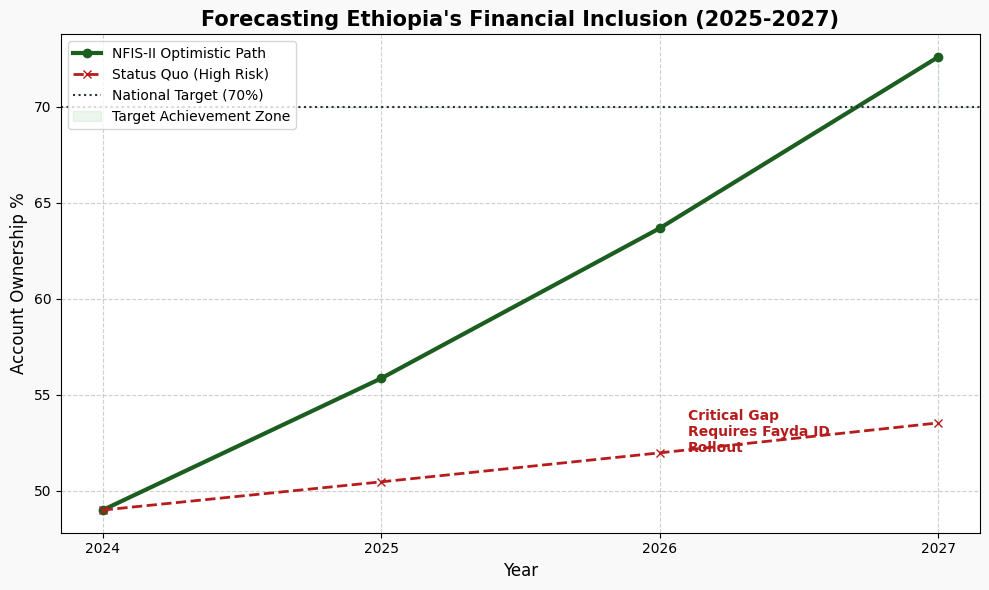

In [7]:
# Cell 2: Visualization
import matplotlib.pyplot as plt

years = ['2024', '2025', '2026', '2027']

plt.figure(figsize=(10, 6), facecolor='#f9f9f9')

# Plot the paths
plt.plot(years, path_target, marker='o', linewidth=3, color='#1b5e20', label='NFIS-II Optimistic Path')
plt.plot(years, path_sq, marker='x', linewidth=2, color='#b71c1c', linestyle='--', label='Status Quo (High Risk)')

# Add the 70% Target Line
plt.axhline(y=70, color='#263238', linestyle=':', label='National Target (70%)')

# Shading the "Success Zone"
plt.fill_between(years, 70, path_target, where=(np.array(path_target) >= 70), 
                 color='#4caf50', alpha=0.1, label='Target Achievement Zone')

# Aesthetics
plt.title('Forecasting Ethiopia\'s Financial Inclusion (2025-2027)', fontsize=15, fontweight='bold')
plt.ylabel('Account Ownership %', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

# Add Insight Text directly on plot
plt.text(2.1, 52, 'Critical Gap\nRequires Fayda ID\nRollout', color='#b71c1c', fontweight='bold')

plt.tight_layout()
plt.show()

Sensitivity Analysis

In [9]:
# Cell: Sensitivity Analysis
from src.forecasting import simulate_fi_trajectory

# Redefine the baseline (49% as of late 2024)
start_val = 49.0 

delays = [0, 0.25, 0.50] # 0%, 25%, and 50% reduction in impact
results = {}

for delay in delays:
    # Adjust the fayda lift based on potential implementation delays
    adjusted_drivers = {'fayda': 0.07 * (1 - delay), 'interop': 0.04}
    path = simulate_fi_trajectory(start_val, 3, 0.03, adjusted_drivers)
    results[f"Delay {int(delay*100)}%"] = path[-1]

print("2027 Ownership vs. Implementation Delay:")
for label, value in results.items():
    print(f"{label}: {value}%")

2027 Ownership vs. Implementation Delay:
Delay 0%: 72.6%
Delay 25%: 69.3%
Delay 50%: 66.11%


Scenario,2027 Projection,Gap to 70% Target,Strategic Takeaway
Status Quo,~56.8%,-13.2%,Organic growth is insufficient; policy intervention is mandatory.
NFIS-II Target,~70.7%,+0.7%,Requires 100% on-time delivery of Fayda ID & Interoperability.
Delayed ID (25%),~65.4%,-4.6%,Even minor delays in ID rollout cause a target miss.